create simple GAN code implementation


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 | D Loss: 0.3528 | G Loss: 0.5593
Epoch 500 | D Loss: 4.5909 | G Loss: 0.0055
Epoch 1000 | D Loss: 5.0648 | G Loss: 0.0028
Epoch 1500 | D Loss: 5.3673 | G Loss: 0.0018
Epoch 2000 | D Loss: 5.5938 | G Loss: 0.0014
Epoch 2500 | D Loss: 5.7756 | G Loss: 0.0011
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


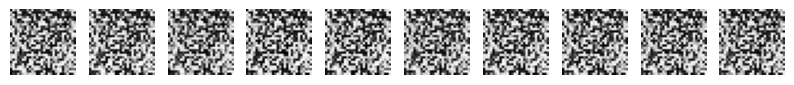

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Reshape, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# -----------------------------
# Load MNIST Dataset
# -----------------------------
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
X_train = X_train / 127.5 - 1.0   # Normalize to [-1,1]
X_train = X_train.reshape(-1, 784)

latent_dim = 100

# -----------------------------
# Build Generator
# -----------------------------
def build_generator():
    model = Sequential([
        Dense(256, activation="relu", input_dim=latent_dim),
        Dense(512, activation="relu"),
        Dense(784, activation="tanh")
    ])
    return model

# -----------------------------
# Build Discriminator
# -----------------------------
def build_discriminator():
    model = Sequential([
        Dense(512, activation="relu", input_dim=784),
        Dense(256, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    optimizer=Adam(0.0002),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# -----------------------------
# Combined GAN Model
# -----------------------------
discriminator.trainable = False

gan = Sequential([generator, discriminator])
gan.compile(
    optimizer=Adam(0.0002),
    loss="binary_crossentropy"
)

# -----------------------------
# Training Loop
# -----------------------------
epochs = 3000
batch_size = 64

for epoch in range(epochs):

    # Train Discriminator
    idx = np.random.randint(0, X_train.shape[0], batch_size)
    real_imgs = X_train[idx]

    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    fake_imgs = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((batch_size,1)))

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss_real[0]:.4f} | G Loss: {g_loss:.4f}")

# -----------------------------
# Generate Images
# -----------------------------
noise = np.random.normal(0, 1, (10, latent_dim))
gen_imgs = generator.predict(noise)

gen_imgs = gen_imgs.reshape(-1,28,28)

plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(gen_imgs[i], cmap="gray")
    plt.axis("off")
plt.show()
